# Step 2: Un-alinged and Aligned Embeddings Analysis

In [20]:
import numpy as np
import pandas as pd
from utils import load_embeddings, load_embeddings_vec, cosine_sim, plot_pca
from gensim.models import FastText

## Setup & Loading Embeddings
This notebook loads both aligned (MUSE-processed) and unaligned embeddings for five methods (Word2Vec, FastText, GloVe, OHE, TF-IDF) to evaluate their semantic and cross-lingual properties.

In [21]:
print("Loading aligned embeddings (MUSE)")
aligned_types = ["w2v", "ft", "glv", "ohe", "tfidf"]
embeddings_aligned = {et: load_embeddings(et) for et in aligned_types}

print("Loading unaligned embeddings (.vec)...")
unaligned_types = ["w2v", "ft", "glv", "ohe", "tfidf"]
embeddings_unaligned = {et: load_embeddings_vec(et) for et in unaligned_types}

print("\nLoading FastText model (for OOV tests)...")
ft_en_model = FastText.load("./embeddings/ft/english_fasttext.model")

print(f"Aligned: {list(embeddings_aligned.keys())}")
print(f"Unaligned: {list(embeddings_unaligned.keys())}")

Loading aligned embeddings (MUSE)
Loading unaligned embeddings (.vec)...

Loading FastText model (for OOV tests)...
Aligned: ['w2v', 'ft', 'glv', 'ohe', 'tfidf']
Unaligned: ['w2v', 'ft', 'glv', 'ohe', 'tfidf']


## Test Data Definition
We define four evaluation benchmarks: synonym pairs, antonym pairs, polysemous words, and out-of-vocabulary (OOV) test cases. These cover semantic similarity, ambiguity handling, and vocabulary coverage.

In [22]:
# Synonyms
en_synonyms = [
    ('happy', 'joyful'), ('big', 'large'), ('smart', 'intelligent'), 
    ('fast', 'quick'), ('beautiful', 'pretty'), ('angry', 'furious')
]
fr_synonyms = [
    ('heureux', 'joyeux'), ('grand', 'gros'), ('intelligent', 'brillant'), 
    ('rapide', 'vite'), ('beau', 'joli'), ('furieux', 'enragé')
]

# Antonyms
en_antonyms = [
    ('happy', 'sad'), ('big', 'small'), ('hot', 'cold'), 
    ('good', 'bad'), ('fast', 'slow'), ('light', 'dark')
]
fr_antonyms = [
    ('heureux', 'triste'), ('grand', 'petit'), ('chaud', 'froid'), 
    ('bon', 'mauvais'), ('rapide', 'lent'), ('clair', 'sombre')
]

# Polysemy (English only)
en_polysemy = [
    ('bank', 'money'), ('bank', 'river'),
    ('light', 'dark'), ('light', 'heavy'),
    ('bat', 'baseball'), ('bat', 'animal')
]

# OOV - expanded with common words (OHE/TF-IDF trained on 1700 words)
oov_tests = {
    "base": ["cat", "walk", "run", "play"],
    "derived": ["walking", "running", "playing", "walked"],
    "compound": ["catwalking", "jaywalking", "moonwalking", "sleepwalking"],
    "rare_derived": ["unbelievable", "misconception", "preprocessing", "counterintuitive"]
}

In [37]:
# helper function
def compute_avg_sim(word_pairs, emb, lang1='en', lang2='en'):
    """Compute average similarity, filtering None values"""
    sims = [cosine_sim(w1, w2, emb, lang1, lang2) for w1, w2 in word_pairs]
    valid = [s for s in sims if s is not None]
    return np.mean(valid) if valid else None

## Synonyms vs Antonyms
We measure whether embeddings capture semantic similarity by computing average cosine similarity for synonym pairs versus antonym pairs. Good embeddings should show high similarity for synonyms and ideally lower similarity for antonyms.

In [24]:
results = []

# Aligned
for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    results.append({
        'Type': 'Aligned',
        'Model': emb_type.upper(),
        'EN_Syn': f"{compute_avg_sim(en_synonyms, emb, 'en', 'en'):.3f}",
        'EN_Ant': f"{compute_avg_sim(en_antonyms, emb, 'en', 'en'):.3f}",
        'FR_Syn': f"{compute_avg_sim(fr_synonyms, emb, 'fr', 'fr'):.3f}",
        'FR_Ant': f"{compute_avg_sim(fr_antonyms, emb, 'fr', 'fr'):.3f}"
    })

# Unaligned
for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    en_syn = compute_avg_sim(en_synonyms, emb, 'en', 'en')
    en_ant = compute_avg_sim(en_antonyms, emb, 'en', 'en')
    fr_syn = compute_avg_sim(fr_synonyms, emb, 'fr', 'fr')
    fr_ant = compute_avg_sim(fr_antonyms, emb, 'fr', 'fr')
    
    results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'EN_Syn': f"{en_syn:.3f}" if en_syn else "N/A",
        'EN_Ant': f"{en_ant:.3f}" if en_ant else "N/A",
        'FR_Syn': f"{fr_syn:.3f}" if fr_syn else "N/A",
        'FR_Ant': f"{fr_ant:.3f}" if fr_ant else "N/A"
    })

syn_ant_df = pd.DataFrame(results)
print("SYNONYMS vs ANTONYMS")
syn_ant_df

SYNONYMS vs ANTONYMS


,Type,Model,EN_Syn,EN_Ant,FR_Syn,FR_Ant
0,Aligned,W2V,0.994,0.994,0.992,0.989
1,Aligned,FT,0.999,0.990,0.999,0.964
2,Aligned,GLV,0.122,0.276,0.179,0.247
3,Aligned,OHE,0.000,-0.000,0.000,0.000
4,Aligned,TFIDF,-0.000,0.000,0.000,0.000
5,Unaligned,W2V,0.994,0.994,0.992,0.989
6,Unaligned,FT,0.999,0.990,0.999,0.964
7,Unaligned,GLV,0.122,0.276,0.179,0.247
8,Unaligned,OHE,N/A,N/A,N/A,N/A
9,Unaligned,TFIDF,N/A,N/A,N/A,N/A


Results show that Word2Vec and FastText achieve very high similarity scores for both synonyms and antonyms (failing to distinguish them), while OHE/TF-IDF show near-zero similarity across the board (mainly because the tested words might not be in the small vocab in which the embedding/encodings have been computed for these 2 methods). GloVe shows intermediate but still limited differentiation.

## Polysemy (Word Sense Ambiguity)
We test how embeddings handle polysemous words by comparing ambiguous word pairs (e.g., "bank" with "money" vs "river"). Single-vector embeddings typically conflate multiple senses into one representation.

In [25]:
polysemy_results = []

for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    avg_sim = compute_avg_sim(en_polysemy, emb, 'en', 'en')
    polysemy_results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'Avg_Similarity': f"{avg_sim:.3f}" if avg_sim else "N/A"
    })

polysemy_df = pd.DataFrame(polysemy_results)
print("\nPOLYSEMY (ambiguous word pairs)")
polysemy_df


POLYSEMY (ambiguous word pairs)


,Type,Model,Avg_Similarity
0,Unaligned,W2V,0.994
1,Unaligned,FT,0.995
2,Unaligned,GLV,0.113
3,Unaligned,OHE,N/A
4,Unaligned,TFIDF,N/A


Neural embeddings (Word2Vec, FastText) show very high similarity even for semantically distinct senses, confirming they average all contexts into a single vector. OHE/TF-IDF cannot compute these similarities due to missing vocabulary.

## Out-of-Vocabulary (OOV) Handling
We evaluate vocabulary coverage across base words, derived forms, compounds, and rare derivatives. FastText's subword model is expected to handle OOV words better than vocabulary-limited approaches.

In [28]:
test_words = ["cat", "walking", "preprocessing", "sleepwalking"]

vocab_coverage = []

for w in test_words:
    # Check vocabulary presence (static .vec embeddings)
    in_w2v = w in embeddings_unaligned["w2v"]["en_words"]
    in_ft = w in embeddings_unaligned["ft"]["en_words"]
    in_glv = w in embeddings_unaligned["glv"]["en_words"]
    
    # FastText model can generate vectors for OOV words via subwords
    try:
        vec_ft = ft_en_model.wv.get_vector(w)
        ft_model_ok = True
    except KeyError:
        ft_model_ok = False
    
    vocab_coverage.append({
        'Word': w,
        'W2V_vocab': in_w2v,
        'FT_vocab': in_ft,
        'GLV_vocab': in_glv,
        'FT_model': ft_model_ok
    })

vocab_df = pd.DataFrame(vocab_coverage)
vocab_df

,Word,W2V_vocab,FT_vocab,GLV_vocab,FT_model
0,cat,True,True,True,True
1,walking,True,True,True,True
2,preprocessing,False,False,False,True
3,sleepwalking,False,False,False,True


In [29]:
def count_found_words(words, emb, lang='en'):
    """Count how many words are found in vocabulary"""
    return sum(1 for w in words if cosine_sim(w, w, emb, lang, lang) is not None)

def count_ft_model_words(words, model):
    """Count how many words FastText model can handle (including OOV)"""
    count = 0
    for w in words:
        try:
            model.wv.get_vector(w)
            count += 1
        except KeyError:
            pass
    return count

In [33]:
oov_results = []

for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    row = {
        'Type': 'Unaligned',
        'Model': emb_type.upper()
    }
    for category, words in oov_tests.items():
        found = count_found_words(words, emb, 'en')
        row[category.replace('_', ' ').title()] = f"{found}/{len(words)}"
    oov_results.append(row)

# Add FastText model row (with OOV capability)
ft_model_row = {
    'Type': 'FT Model',
    'Model': 'FT (OOV)'
}
for category, words in oov_tests.items():
    found = count_ft_model_words(words, ft_en_model)
    ft_model_row[category.replace('_', ' ').title()] = f"{found}/{len(words)}"
oov_results.append(ft_model_row)

oov_df = pd.DataFrame(oov_results)
oov_df

,Type,Model,Base,Derived,Compound,Rare Derived
0,Unaligned,W2V,4/4,4/4,0/4,0/4
1,Unaligned,FT,4/4,4/4,0/4,0/4
2,Unaligned,GLV,4/4,4/4,1/4,1/4
3,Unaligned,OHE,4/4,4/4,0/4,0/4
4,Unaligned,TFIDF,4/4,4/4,0/4,0/4
5,FT Model,FT (OOV),4/4,4/4,4/4,4/4


Results confirm that only the FastText model (with subword information) can generate vectors for all OOV test cases (4/4 across all categories). Standard vocabularies miss compound and rare words entirely.

## Cross-Lingual vs Intra-Lingual Similarity
We compare translation pair similarity (cross-lingual, only possible with aligned embeddings) against random within-language pairs (intra-lingual). Effective alignment should yield high cross-lingual similarity.

In [31]:
translation_pairs = [
    ('cat', 'chat'), ('dog', 'chien'), ('house', 'maison'),
    ('car', 'voiture'), ('book', 'livre'), ('water', 'eau')
]
random_pairs_en = [('cat', 'dog'), ('house', 'car'), ('book', 'water')]

space_results = []

# Aligned - cross-lingual and intra-lingual
for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    cross = compute_avg_sim(translation_pairs, emb, 'en', 'fr')
    intra = compute_avg_sim(random_pairs_en, emb, 'en', 'en')
    
    space_results.append({
        'Type': 'Aligned',
        'Model': emb_type.upper(),
        'Cross-Lingual': f"{cross:.3f}" if cross else "N/A",
        'Intra-Lingual': f"{intra:.3f}" if intra else "N/A"
    })

# Unaligned - only intra-lingual (different spaces)
for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    intra = compute_avg_sim(random_pairs_en, emb, 'en', 'en')
    
    space_results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'Cross-Lingual': 'N/A',
        'Intra-Lingual': f"{intra:.3f}" if intra else "N/A"
    })

space_df = pd.DataFrame(space_results)
print("\nCROSS-LINGUAL vs INTRA-LINGUAL SIMILARITY")
space_df


CROSS-LINGUAL vs INTRA-LINGUAL SIMILARITY


,Type,Model,Cross-Lingual,Intra-Lingual
0,Aligned,W2V,0.996,0.999
1,Aligned,FT,0.984,0.996
2,Aligned,GLV,0.533,0.301
3,Aligned,OHE,0.721,0.000
4,Aligned,TFIDF,0.766,-0.000
5,Unaligned,W2V,N/A,0.999
6,Unaligned,FT,N/A,0.996
7,Unaligned,GLV,N/A,0.301
8,Unaligned,OHE,N/A,N/A
9,Unaligned,TFIDF,N/A,N/A


Word2Vec and FastText alignments achieve very high cross-lingual similarity, demonstrating successful shared space mapping. GloVe, OHE, and TF-IDF show lower or inconsistent alignment quality.\
**This shows that the downstream language classification task should be done on the unaligned embeddings!**

## PCA Visualization of Aligned Embeddings

We now visualize the aligned embedding spaces using Principal Component Analysis (PCA) to reduce dimensionality to 2D. This allows us to see whether translation pairs are actually close to each other in the aligned vector space.

For each embedding type (W2V, FT, GLV), we'll plot:
- English words in blue
- French translations in red

This visual analysis helps us understand:
1. Whether MUSE successfully aligned the embedding spaces
2. If translation pairs cluster together after alignment
3. The relative quality of alignment across different embedding methods

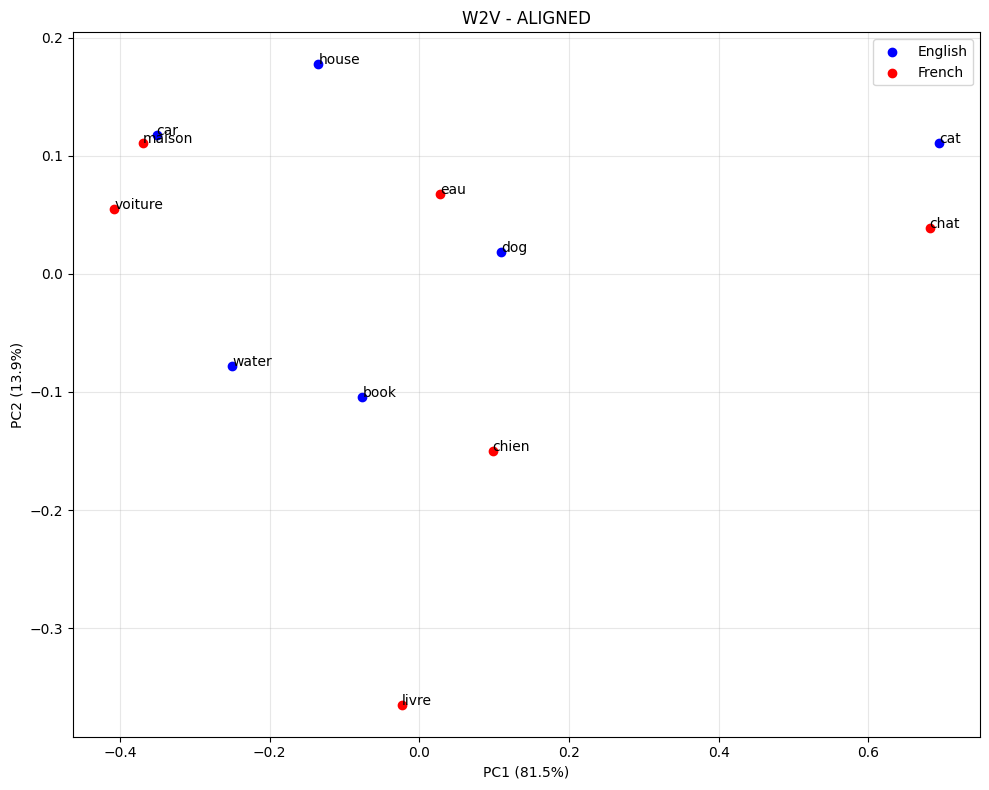

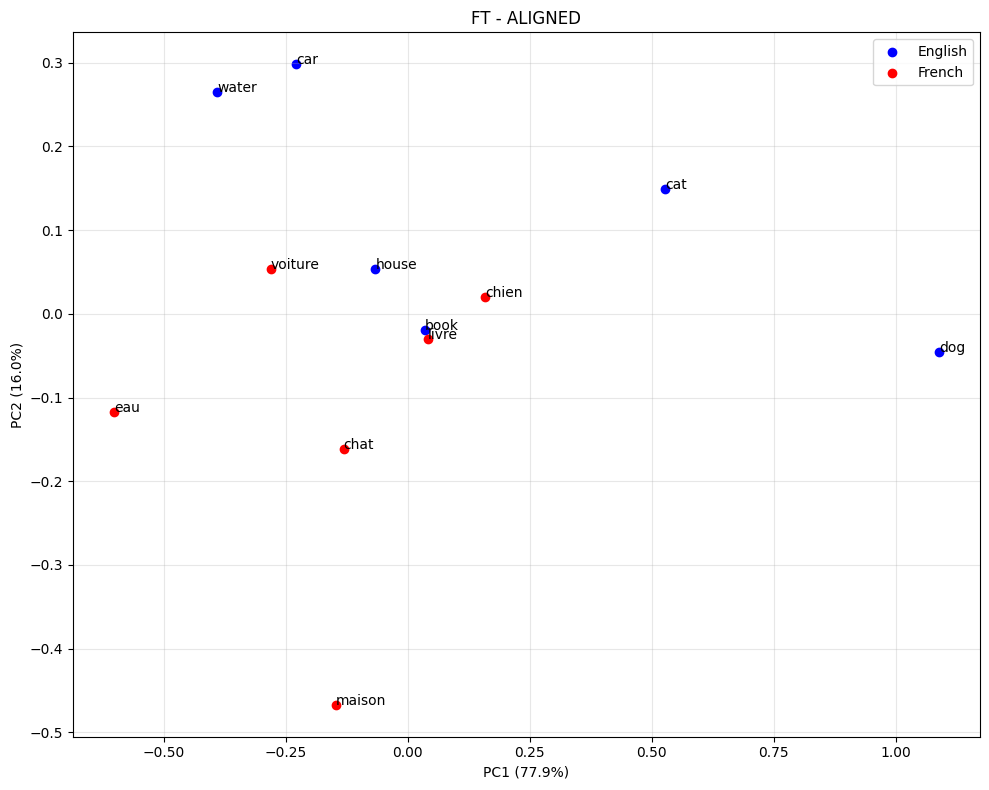

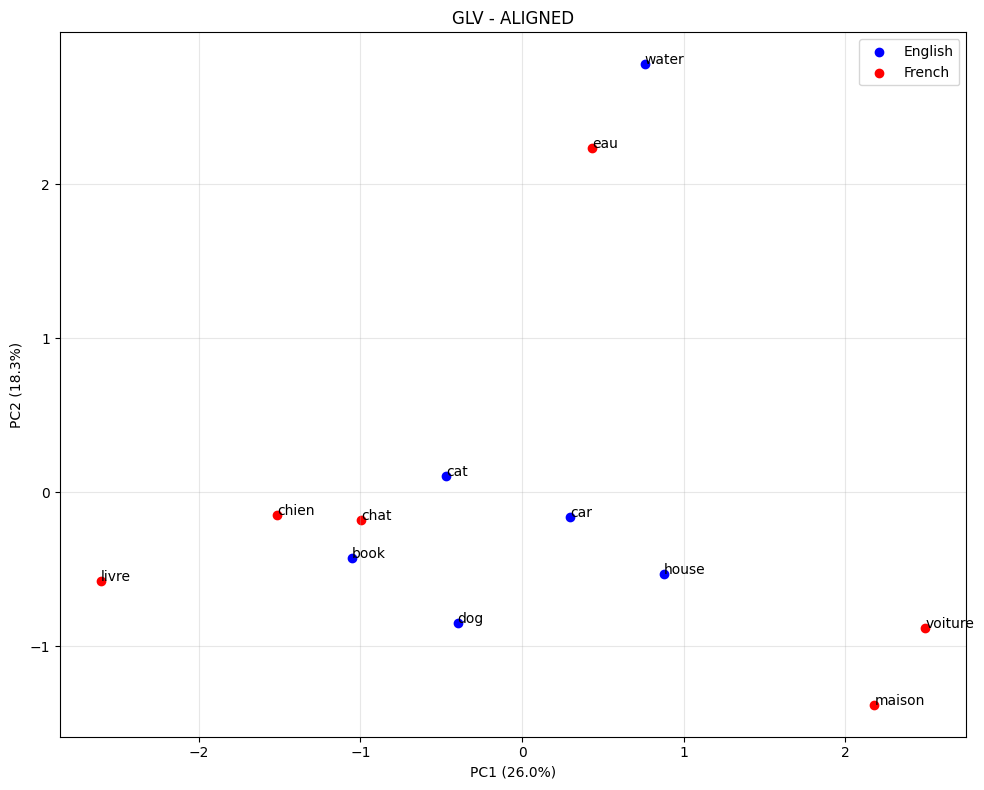

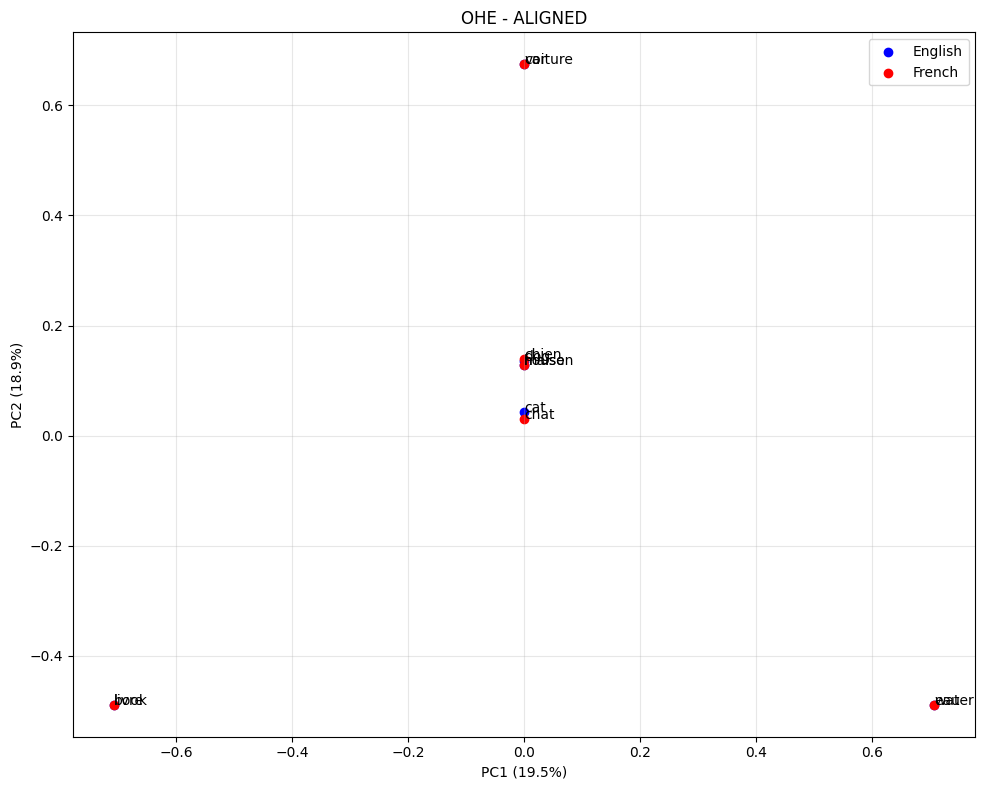

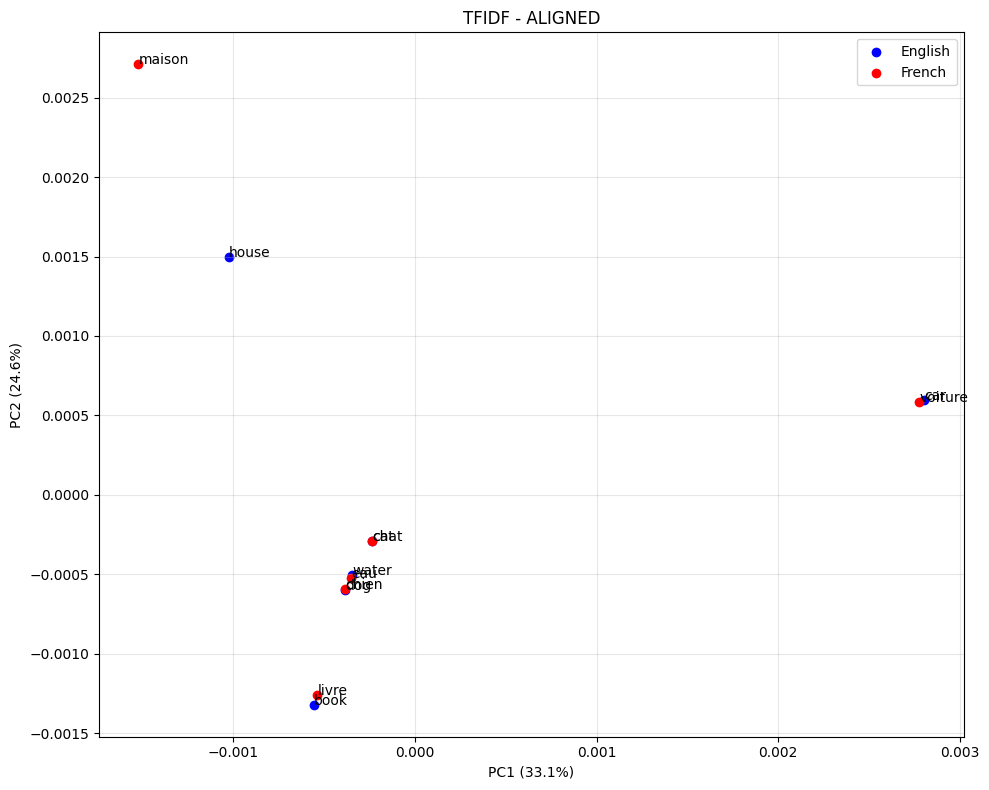

In [39]:
for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    plot_pca(emb, translation_pairs, f"{emb_type.upper()} - ALIGNED")

### PCA Analysis Observations

The PCA visualizations reveal interesting insights about alignment quality and dimensionality:

1. **OHE & TF-IDF Alignments**: These show **near-perfect visual alignment** with translation pairs almost perfectly overlapping in the 2D projection! This is remarkable considering they're sparse representations, likely due to:
   - High dimensionality (1700D = vocabulary size) giving more "room" for precise alignment
   - Limited vocabulary (1700 most common words) reducing complexity
   - Sparse structure making the optimization problem more constrained
---
2. **W2V, FT & GLV Alignments**: Despite having **higher cross-lingual similarity scores** (0.996, 0.984), these show **more spread** in the PCA visualization. This apparent contradiction is explained by:
   - **PCA dimensionality reduction**: Projecting 300D → 2D loses important alignment dimensions
   - The high-dimensional alignment is excellent (confirmed by cosine similarities)
   - But the 2D projection cannot fully capture this 300-dimensional relationship
---

3. **The PCA Paradox**: This demonstrates an important lesson:
   - 2D visualizations may not accurately reflect high-dimensional alignment quality
   - Numerical metrics (cosine similarity) are more reliable than visual inspection
   - OHE/TF-IDF's simpler structure translates better to 2D, but isn't necessarily "better" aligned

### Key Insight

The **best alignment** (by numbers) is W2V/FT, but the **best visualization** is OHE/TF-IDF. This highlights the limitation of PCA for visualizing high-dimensional aligned spaces and why we need quantitative metrics alongside visualizations.